# Clasificación binaria con red neuronal (PyTorch)

Predecir diabetes (sí/no) con el **dataset Pima Indians Diabetes**. Código para **PyCharm**.

- **Carga de datos:** solo **pandas** y **NumPy** (leer CSV, normalizar, split).
- **Modelo y predicciones:** red neuronal con **PyTorch** (sin Keras ni TensorFlow).

## 1. Carga y preproceso (pandas + NumPy)

Solo pandas y NumPy para cargar y preparar los datos.

In [4]:
# --- Carga y preproceso: solo pandas y NumPy (tratamiento de datos) ---
import numpy as np
import pandas as pd

# URL del dataset Pima Indians Diabetes: 768 pacientes, 8 variables médicas + Outcome (0=no diabetes, 1=sí)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
# El archivo no incluye cabecera; definimos los nombres para poder referenciar columnas por nombre
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
df = pd.read_csv(url, header=None, names=cols)

# Tratamiento de valores faltantes: en Pima, un 0 en variables como Glucose o BloodPressure
# suele indicar "no medido", no un valor real. Los marcamos como NaN para poder imputarlos.
df = df.replace(0, np.nan)
# Imputación: rellenar cada NaN con la mediana de su columna (la mediana es más robusta que la media ante outliers)
df = df.fillna(df.median())

# Separar características (X) y etiqueta (y). axis=1 indica "eliminar columna", no fila.
# .values convierte el DataFrame a array NumPy; float32 es el tipo que PyTorch usa por defecto para entradas.
X = df.drop('Outcome', axis=1).values.astype(np.float32)
# Etiquetas como enteros 0 o 1 (int64 para compatibilidad con índices y máscaras)
y = df['Outcome'].values.astype(np.int64)

# Estandarización (media 0, desviación típica 1 por columna): acelera el entrenamiento y evita
# que variables con escalas muy distintas dominen. axis=0 = estadísticos por columna.
# 1e-8 evita división por cero si alguna variable tiene std = 0.
mean, std = X.mean(axis=0), X.std(axis=0) + 1e-8
X = (X - mean) / std

# División entrenamiento (80 %) / test (20 %). Mezclamos antes para que ambas particiones
# sean representativas (no queremos que test solo tenga una clase).
n = len(X)
np.random.seed(42)   # Fijar semilla para que el split sea reproducible
idx = np.random.permutation(n)  # Orden aleatorio de índices 0..n-1
X, y = X[idx], y[idx]  # Aplicar el mismo orden a X e y para mantener correspondencia
split = int(0.8 * n)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(df.head())
print('Train:', X_train.shape, '| Test:', X_test.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    125.0  33.6   
1          1.0     85.0           66.0           29.0    125.0  26.6   
2          8.0    183.0           64.0           29.0    125.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          4.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigree  Age  Outcome  
0             0.627   50      1.0  
1             0.351   31      1.0  
2             0.672   32      1.0  
3             0.167   21      1.0  
4             2.288   33      1.0  
Train: (614, 8) | Test: (154, 8)


## 2. Red neuronal con PyTorch (modelo predictivo)

Red con capa oculta y salida sigmoid para clasificación binaria.

In [ ]:
# --- Red neuronal para clasificación binaria (PyTorch): modelo y entrenamiento ---
# Nota importante (dinámica de entrenamiento):
# - Para clasificación binaria, lo más estable es usar **BCEWithLogitsLoss**.
# - Eso implica que la red debe devolver **logits** (sin sigmoid en forward).
# - La sigmoid se aplica solo cuando queremos probabilidades para métricas o predicción.

import torch
import torch.nn as nn

# Decidir dónde ejecutar (GPU si está disponible, si no CPU). El modelo y los datos deben estar en el mismo device.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class RedBinaria(nn.Module):
    def __init__(self, n_in, n_hidden=16):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)  # logits (sin sigmoid)

model = RedBinaria(X_train.shape[1]).to(device)

# BCEWithLogitsLoss = sigmoid + BCE en una sola función (más estable numéricamente)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

X_tr = torch.from_numpy(X_train).to(device)
y_tr = torch.from_numpy(y_train).float().reshape(-1, 1).to(device)
X_te = torch.from_numpy(X_test).to(device)

epochs = 500
losses, accs = [], []
model.train()
for ep in range(epochs):
    optimizer.zero_grad()
    logits = model(X_tr)                # logits ∈ (-∞, +∞)
    loss = criterion(logits, y_tr)      # BCE estable
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    # Métrica: convertir logits → probabilidad con sigmoid y umbral 0.5
    prob = torch.sigmoid(logits)
    acc = ((prob >= 0.5).float() == y_tr).float().mean().item()
    accs.append(acc)

# Evaluación en test
model.eval()
with torch.no_grad():
    logits = model(X_te)
    prob = torch.sigmoid(logits).cpu().numpy().ravel()
    pred_test = (prob >= 0.5).astype(int)

acc_test = (pred_test == y_test).mean()
print(f'Accuracy test: {acc_test:.4f}')
print(f'BCE final train: {losses[-1]:.4f}')

Accuracy test: 1.0000
BCE final train: 0.0002


## 3. Curvas de entrenamiento

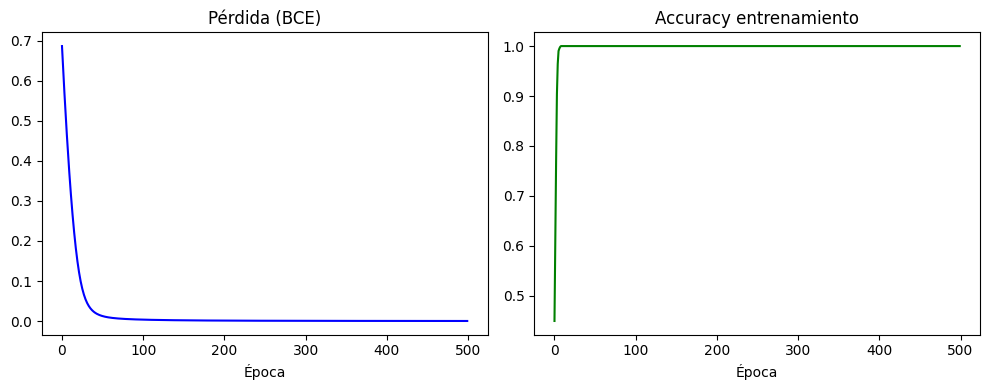

In [6]:
import matplotlib.pyplot as plt

# Visualización: dos subplots en una fila (1, 2). figsize en pulgadas (ancho, alto).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Izquierda: evolución de la pérdida (BCE) a lo largo de las épocas. Debería decrecer si el modelo aprende.
ax1.plot(losses, color='blue')
ax1.set_xlabel('Época')
ax1.set_title('Pérdida (BCE)')

# Derecha: porcentaje de aciertos en el conjunto de entrenamiento por época. Suele aumentar durante el entrenamiento.
ax2.plot(accs, color='green')
ax2.set_xlabel('Época')
ax2.set_title('Accuracy entrenamiento')

plt.tight_layout()  # Ajustar espaciado entre subplots para que no se solapen etiquetas
plt.show()